# Notebook 02 — Picking P and S Arrivals

**Goal.** Identify the **first arrivals** of the P-wave and S-wave on
each station's seismogram and record them as a **sample index**.

In Notebook 01 we synthesized 8-station seismograms from a known
hypocenter at $(x, y, z) = (5, -3, 9)$ km, $t_0 = 0$ s. (You shouldn't
peek at those numbers yet — they're saved in `data/ground_truth.pkl`
and we'll only reveal them at the end of this notebook to grade your
picks.)

The picks you produce here will be the **only data** the inversion
notebooks see. With sloppy picks, even the best inversion algorithm
will give wrong locations. So this exercise matters.

**Convention.** A pick is an integer sample index $k$ such that the
arrival happens at time $k \cdot \Delta t = k \cdot 0.01\,\mathrm{s}$
after the start of the trace. Sample $k = 0$ is the very first sample.

**Picking strategy.**

- The **P arrival** is usually clearest on the **Z (vertical)** trace,
  because P-wave motion is largely along the ray direction (and rays
  arrive nearly vertically at short range). Look for the *first
  coherent deflection* above the noise.
- The **S arrival** is clearest on the **horizontal traces (N, E)**,
  often with much larger amplitude. P-coda may already be present
  when S arrives, so the eye looks for an *amplitude jump*, not pure
  silence-then-signal.
- The first arrival is *always* P (S is slower).
- Don't pick the *peak* — pick the *onset* (where the trace first
  departs from background). The peak is later by ~$1/(2 f_c)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle, os

plt.rcParams.update({
    'figure.dpi': 100, 'savefig.dpi': 100,
    'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25,
})

DATA_DIR = '../data'
with open(os.path.join(DATA_DIR, 'network.pkl'), 'rb') as f:
    bundle = pickle.load(f)
NETWORK = bundle['network']
VMODEL  = bundle['vmodel']
STATIONS = bundle['stations']

print(f'Loaded {len(NETWORK)} stations, sampling {NETWORK["S01"]["dt"]*1000:.0f} ms.')
print(f'Trace length: {len(NETWORK["S01"]["Z"])} samples = '
      f'{len(NETWORK["S01"]["Z"]) * NETWORK["S01"]["dt"]:.1f} s.')
print(f'Stations and offsets:')
for name, s in sorted(NETWORK.items(), key=lambda kv: kv[1]['offset']):
    print(f'  {name}: offset = {s["offset"]:5.1f} km')

Loaded 8 stations, sampling 10 ms.
Trace length: 2500 samples = 25.0 s.
Stations and offsets:
  S01: offset =  30.1 km
  S07: offset =  30.2 km
  S06: offset =  32.0 km
  S05: offset =  34.5 km
  S02: offset =  36.2 km
  S04: offset =  37.3 km
  S03: offset =  40.9 km
  S08: offset =  46.1 km


## 1. Network overview — which station do we pick first?

Plot the **vertical (Z) component** of every station, ordered by
epicentral distance. Two visual cues immediately pop out:

- **Move-out**: closer stations have earlier arrivals; farther stations
  have later arrivals. If the picks form a sensible move-out curve,
  they're probably right.
- **Amplitude decay with distance**: closer stations have larger
  amplitudes. Geometric spreading scales the wave as $1/r$.

The **closest station** (smallest offset) is usually the easiest to
pick first — its arrivals are sharpest and earliest.

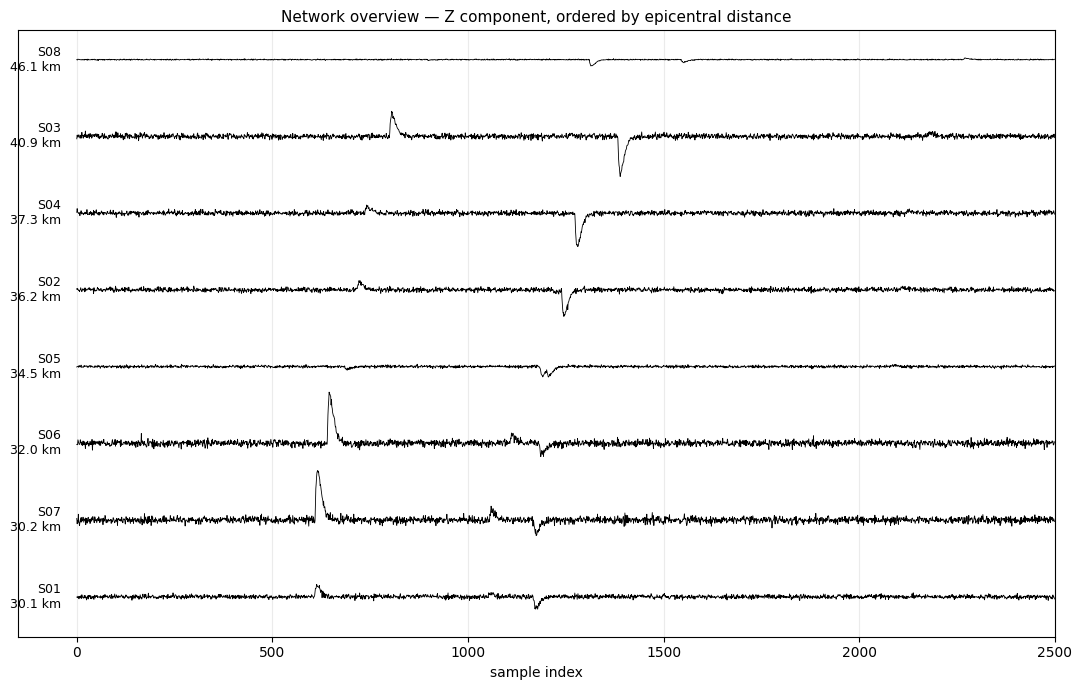

In [2]:
fig, ax = plt.subplots(1, 1, figsize=(11, 7))
ordered = sorted(NETWORK.items(), key=lambda kv: kv[1]['offset'])
peak = max(np.max(np.abs(s['Z'])) for _, s in ordered)
spacing = peak * 1.5
n_samples = len(ordered[0][1]['Z'])

for i, (name, seis) in enumerate(ordered):
    y0 = i * spacing
    samples = np.arange(len(seis['Z']))
    ax.plot(samples, y0 + seis['Z'], 'k', lw=0.6)
    ax.text(-40, y0, f"{name}\n{seis['offset']:.1f} km",
            ha='right', va='center', fontsize=9)

ax.set_yticks([])
ax.set_xlabel('sample index')
ax.set_xlim(-150, n_samples)
ax.set_title('Network overview — Z component, ordered by epicentral distance', fontsize=11)
plt.tight_layout()
plt.show()

## 2. A helper to plot one station with sample-number x-axis

We pick by **sample index**, so it is natural to make the x-axis show
samples instead of seconds. The conversion is just $t = k \cdot dt$.

The function below takes a station name plus optional pick markers
(a dict like `{'P': 1234, 'S': 1567}`) and an optional sample range
to zoom into. Vertical lines show your candidate picks. We'll call
this many times below.

In [3]:
def plot_station(name, network, picks=None, sample_range=None,
                 components=('Z', 'N', 'E'), figsize=(11, 6.5)):
    '''
    Plot 3-component seismogram with sample-index x-axis.

    name         : station name string
    network      : the loaded network dict
    picks        : optional dict, e.g. {'P': 1234, 'S': 1567}
    sample_range : optional (k_start, k_end) tuple to zoom
    '''
    seis = network[name]
    n = len(seis['Z'])
    samples = np.arange(n)
    if sample_range is None:
        k0, k1 = 0, n
    else:
        k0, k1 = sample_range
        k0 = max(0, k0); k1 = min(n, k1)

    fig, axs = plt.subplots(len(components), 1, figsize=figsize, sharex=True)
    if len(components) == 1: axs = [axs]
    for ax, comp in zip(axs, components):
        ax.plot(samples[k0:k1], seis[comp][k0:k1], 'k', lw=0.6)
        ax.set_ylabel(comp)
        if picks is not None:
            for label, k in picks.items():
                if k is None: continue
                color = 'C0' if label.upper().startswith('P') else 'C3'
                ax.axvline(k, color=color, lw=1.2, alpha=0.85,
                           label=f'{label} pick @ {k}')
            ax.legend(loc='upper right', fontsize=8)
    axs[0].set_title(f'Station {name}  (offset {seis["offset"]:.1f} km)',
                     fontsize=11)
    axs[-1].set_xlabel('sample index')
    plt.tight_layout()
    plt.show()

**Demo.** Look at the closest station, S01, in full. The P and S
arrivals should be visually obvious — that's by design (small offset,
sharp signal-to-noise). Try to *guess* the sample indices of the P
and S onsets before zooming in.

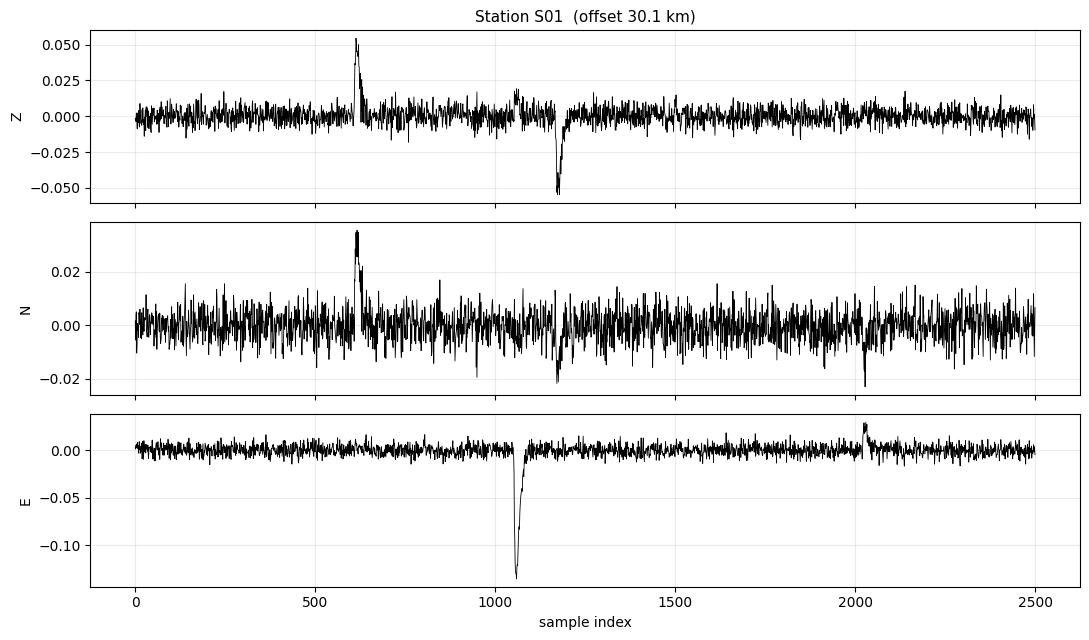

In [4]:
plot_station('S01', NETWORK)

## 3. Zooming in to refine a pick

A full 2500-sample trace is too coarse to pick to single-sample
accuracy. Once you've spotted approximately where the arrival is,
zoom in to a window of ~150–300 samples around it and look for the
*onset* — the first sample where the trace clearly leaves the
background noise.

Below we zoom S01 to the first 600 samples to look for P, then to a
later window to look for S.

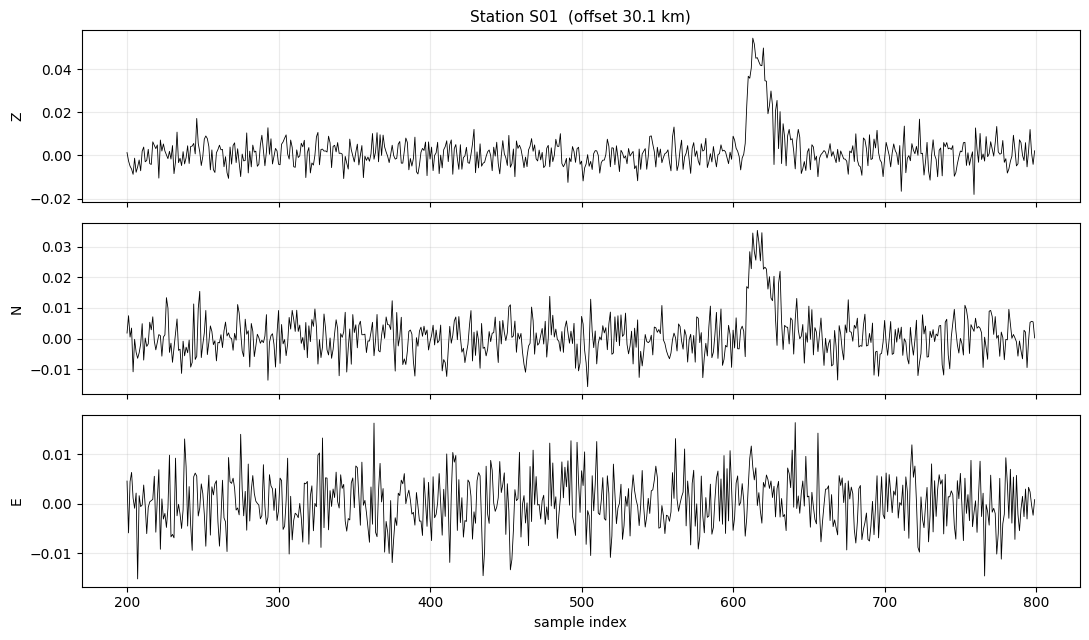

In [5]:
# Zoom 1: early window for P arrival
plot_station('S01', NETWORK, sample_range=(200, 800))

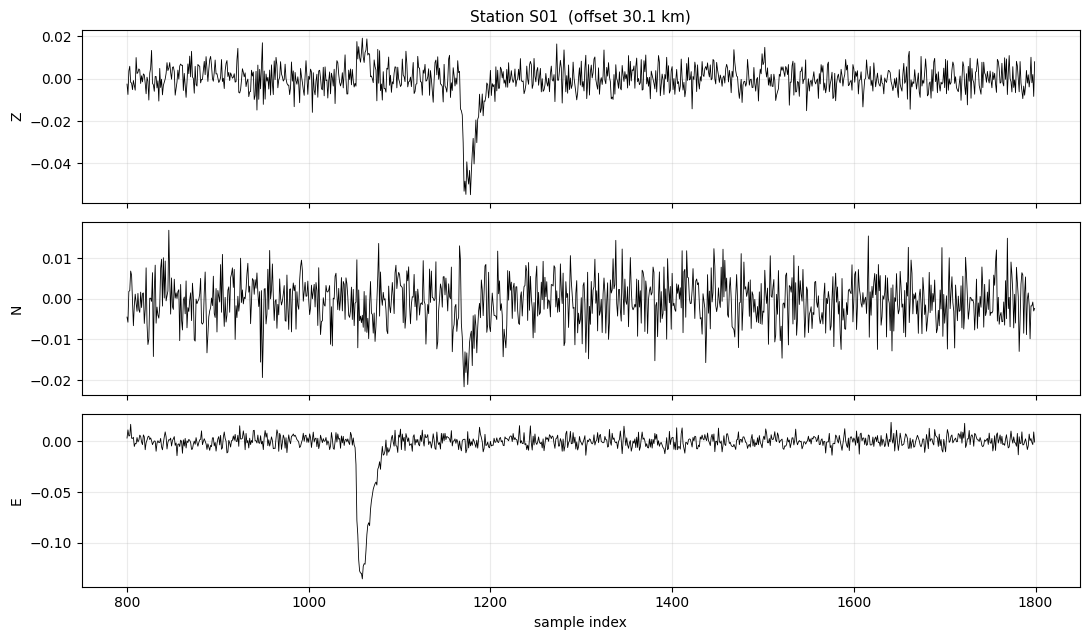

In [6]:
# Zoom 2: later window for S arrival (horizontals carry it)
plot_station('S01', NETWORK, sample_range=(800, 1800))

## 4. STA/LTA — an automatic onset detector

Eyeballing 8 stations × 2 phases is tedious and error-prone, especially
at noisy stations. A standard helper is the **STA/LTA ratio**: the
ratio of short-term average to long-term average of the trace envelope.
A sudden burst of energy makes STA jump while LTA lags, so the ratio
spikes at onsets.

Definition. With trace squared-amplitude $a_k = x_k^2$:

$$
\mathrm{STA}_k = \frac{1}{n_S} \sum_{j=k-n_S+1}^{k} a_j, \qquad
\mathrm{LTA}_k = \frac{1}{n_L} \sum_{j=k-n_L+1}^{k} a_j, \qquad
R_k = \frac{\mathrm{STA}_k}{\mathrm{LTA}_k + \varepsilon}.
$$

Typical values: STA window 0.2 s ($n_S = 20$ samples at 100 Hz), LTA
window 2 s ($n_L = 200$). Pick where $R$ first exceeds a threshold
like 3–5.

**STA/LTA is a *suggestion*, not a verdict.** It misses emergent
arrivals, can trigger on noise spikes, and confuses P-coda with the
S onset. Always verify visually.

In [7]:
def sta_lta(trace, sta_len=20, lta_len=200, eps=1e-9):
    '''
    Classic STA/LTA ratio of the squared-amplitude envelope.

    Returns an array R the same length as trace. R[k] is undefined
    for k < lta_len; we set those to NaN.
    '''
    a = trace.astype(float) ** 2
    # Cumulative-sum trick gives O(N) running averages.
    cs = np.concatenate([[0.0], np.cumsum(a)])
    n = len(trace)
    R = np.full(n, np.nan)
    for k in range(lta_len, n):
        sta = (cs[k+1] - cs[k+1-sta_len]) / sta_len
        lta = (cs[k+1] - cs[k+1-lta_len]) / lta_len
        R[k] = sta / (lta + eps)
    return R


def first_threshold_crossing(R, threshold, k_min=0):
    '''Return the first sample index k >= k_min where R[k] > threshold,
    or None if there is no such crossing.'''
    for k in range(max(k_min, 0), len(R)):
        if not np.isnan(R[k]) and R[k] > threshold:
            return k
    return None

**Demo on S01.** Compute STA/LTA on the Z trace (for P) and on the
horizontal envelope $\sqrt{N^2 + E^2}$ (for S, since S energy lives
on the horizontals). Plot the ratios and mark first-threshold
crossings.

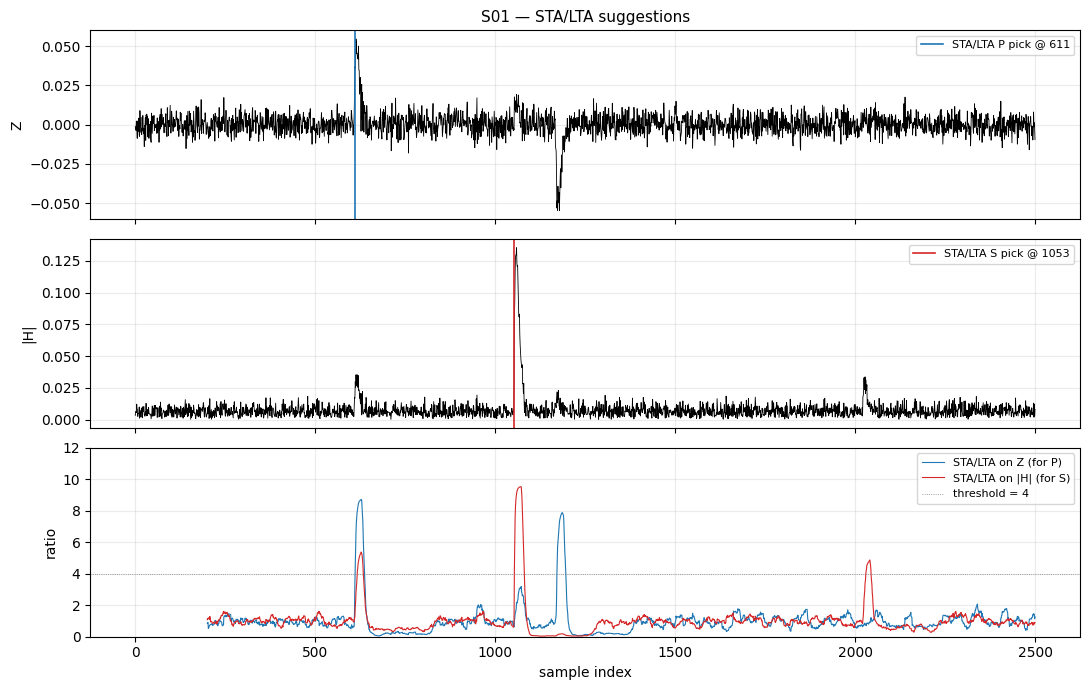

STA/LTA suggestions for S01:  P @ sample 611,  S @ sample 1053


In [8]:
seis = NETWORK['S01']
R_z = sta_lta(seis['Z'], sta_len=20, lta_len=200)
horiz_env = np.sqrt(seis['N']**2 + seis['E']**2)
R_h = sta_lta(horiz_env, sta_len=20, lta_len=200)

p_auto = first_threshold_crossing(R_z, threshold=4.0)
# For S we should look only AFTER the P pick; otherwise STA/LTA on
# horizontals fires on P-induced horizontal motion.
s_auto = first_threshold_crossing(R_h, threshold=4.0,
                                  k_min=(p_auto or 0) + 100)

samples = np.arange(len(seis['Z']))
fig, axs = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axs[0].plot(samples, seis['Z'], 'k', lw=0.6)
axs[0].set_ylabel('Z')
if p_auto is not None:
    axs[0].axvline(p_auto, color='C0', lw=1.2, label=f'STA/LTA P pick @ {p_auto}')
axs[0].legend(loc='upper right', fontsize=8)
axs[0].set_title('S01 — STA/LTA suggestions', fontsize=11)

axs[1].plot(samples, horiz_env, 'k', lw=0.6)
axs[1].set_ylabel('|H|')
if s_auto is not None:
    axs[1].axvline(s_auto, color='C3', lw=1.2, label=f'STA/LTA S pick @ {s_auto}')
axs[1].legend(loc='upper right', fontsize=8)

axs[2].plot(samples, R_z, color='C0', lw=0.8, label='STA/LTA on Z (for P)')
axs[2].plot(samples, R_h, color='C3', lw=0.8, label='STA/LTA on |H| (for S)')
axs[2].axhline(4.0, color='gray', lw=0.6, ls=':', label='threshold = 4')
axs[2].set_ylabel('ratio')
axs[2].set_xlabel('sample index')
axs[2].set_ylim(0, 12)
axs[2].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()
print(f'STA/LTA suggestions for S01:  P @ sample {p_auto},  S @ sample {s_auto}')

**Apply STA/LTA to every station** to get a starting set of picks.
We'll then refine these by eye for stations where the auto-pick looks
suspicious.

In [9]:
def auto_pick(name, network, threshold_p=4.0, threshold_s=4.0,
              sta_len=20, lta_len=200, s_offset=100):
    '''Auto-pick P (on Z) and S (on horizontal envelope) for one station.'''
    seis = network[name]
    R_z = sta_lta(seis['Z'], sta_len, lta_len)
    horiz = np.sqrt(seis['N']**2 + seis['E']**2)
    R_h = sta_lta(horiz, sta_len, lta_len)
    p = first_threshold_crossing(R_z, threshold_p)
    s = first_threshold_crossing(R_h, threshold_s,
                                 k_min=(p or 0) + s_offset)
    return p, s

auto_picks = {}
for name in NETWORK:
    p, s = auto_pick(name, NETWORK)
    auto_picks[name] = {'P': p, 'S': s}

print('Auto-picks (STA/LTA threshold = 4):')
print(f'{"station":>8s}  {"P (sample)":>10s}  {"S (sample)":>10s}  '
      f'{"P time (s)":>10s}  {"S time (s)":>10s}')
for name in sorted(NETWORK.keys()):
    p, s = auto_picks[name]['P'], auto_picks[name]['S']
    dt = NETWORK[name]['dt']
    pt = f'{p*dt:.3f}' if p is not None else '----'
    st = f'{s*dt:.3f}' if s is not None else '----'
    print(f'{name:>8s}  {p!s:>10s}  {s!s:>10s}  {pt:>10s}  {st:>10s}')

Auto-picks (STA/LTA threshold = 4):
 station  P (sample)  S (sample)  P time (s)  S time (s)
     S01         611        1053       6.110      10.530
     S02         722        1242       7.220      12.420
     S03         802        1385       8.020      13.850
     S04         744        1275       7.440      12.750
     S05         694        1186       6.940      11.860
     S06         642        1111       6.420      11.110
     S07         611        1057       6.110      10.570
     S08        1312        1548      13.120      15.480


## 5. Visual review — verify the auto-picks one station at a time

Loop through every station and overlay the STA/LTA suggestions.
For any station where the marker doesn't sit cleanly on the onset,
override the value in the `picks` dictionary below.

When in doubt, **err on the side of slightly late**: a pick a few
samples after the true onset still gives sensible inversion residuals,
but a pick that anticipates the onset (in the noise) is contaminated
by random fluctuations.

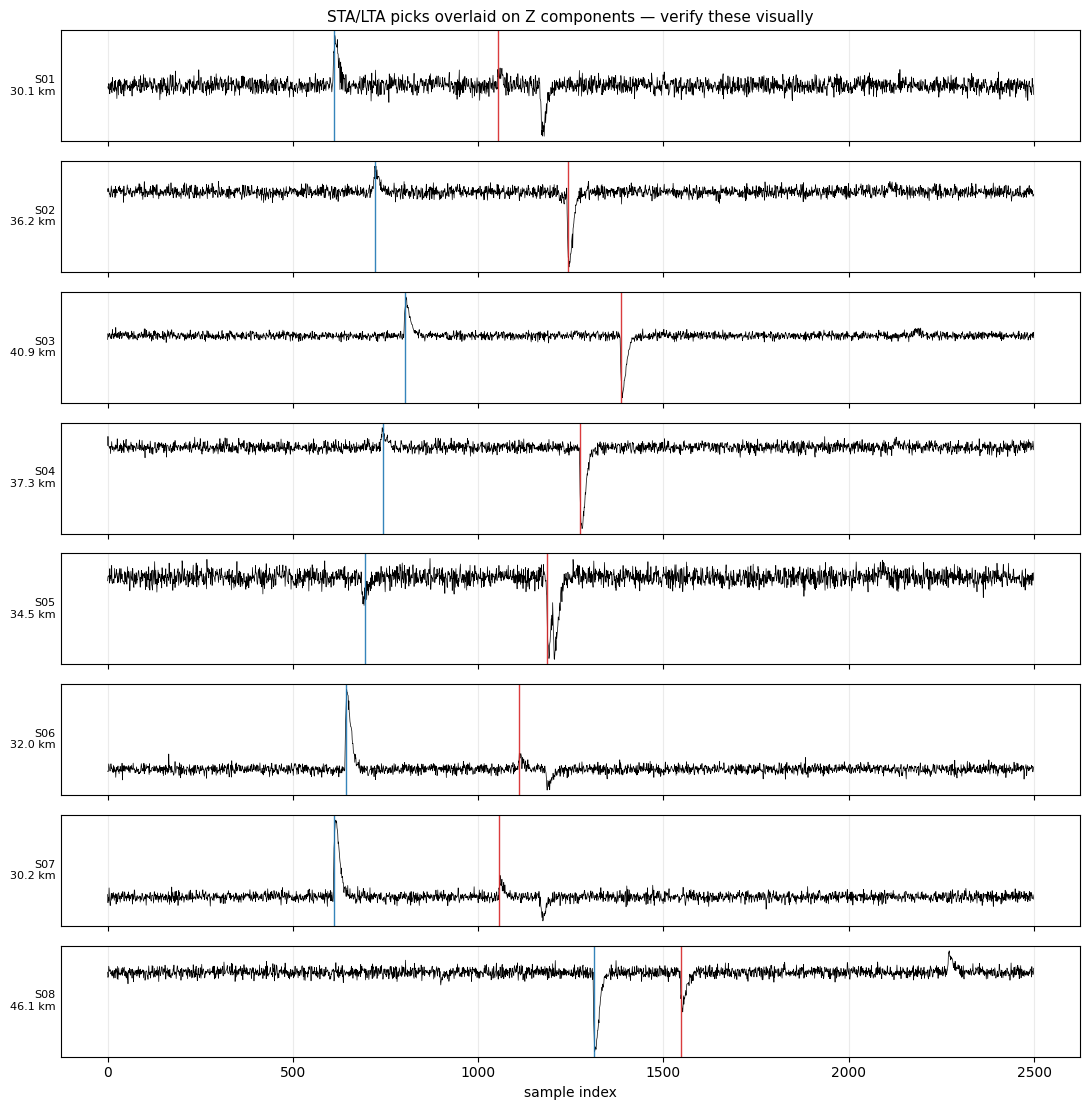

In [10]:
fig, axs = plt.subplots(len(NETWORK), 1, figsize=(11, 1.4*len(NETWORK)),
                        sharex=True)
for ax, name in zip(axs, sorted(NETWORK.keys())):
    seis = NETWORK[name]
    samples = np.arange(len(seis['Z']))
    ax.plot(samples, seis['Z'], 'k', lw=0.5)
    p = auto_picks[name]['P']; s = auto_picks[name]['S']
    if p is not None: ax.axvline(p, color='C0', lw=1.0, alpha=0.9)
    if s is not None: ax.axvline(s, color='C3', lw=1.0, alpha=0.9)
    ax.set_ylabel(f'{name}\n{seis["offset"]:.1f} km', fontsize=8, rotation=0,
                  ha='right', va='center')
    ax.set_yticks([])
axs[-1].set_xlabel('sample index')
axs[0].set_title('STA/LTA picks overlaid on Z components — verify these visually',
                 fontsize=11)
plt.tight_layout()
plt.show()

## 6. Your picks

Copy the auto-picks into a fresh dictionary and refine any that
look off. **This is the only thing the inversion notebooks will see.**

In the per-station overlay above, look closely at the **farthest
station(s)**. Auto-pickers struggle at large offset because direct-P
amplitude has decayed (geometric spreading $\propto 1/r$) while noise
hasn't, and the STA/LTA can latch onto a later, stronger phase like
PmP or even Sg instead of the true P onset. If S08's P marker sits
suspiciously late on the trace, override it after zooming in.

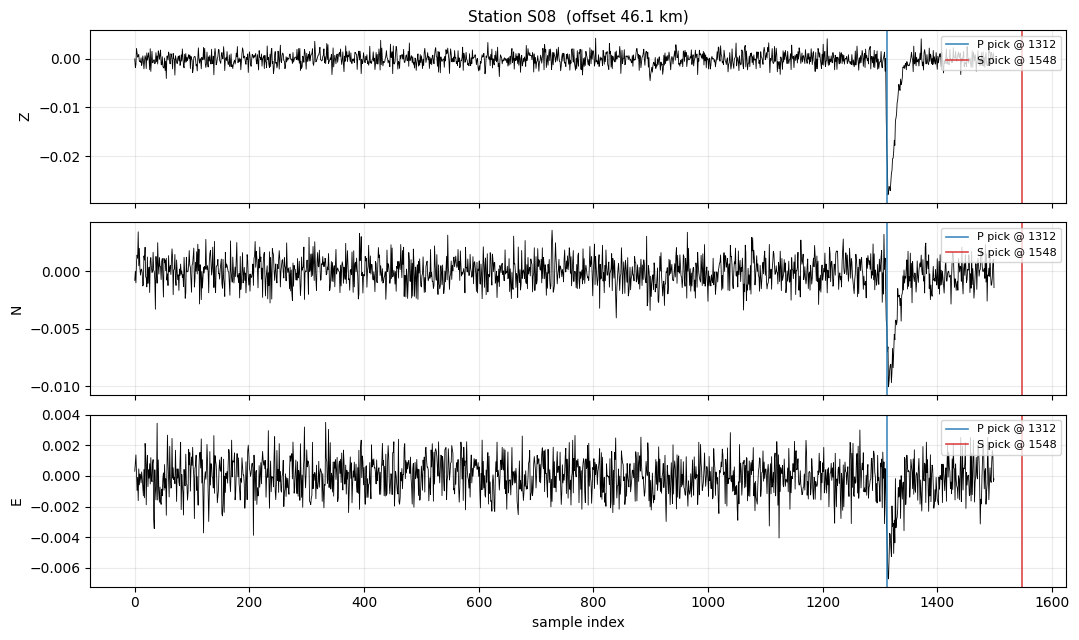

In [11]:
# Inspect the farthest station's first 1500 samples, with the
# auto-pick overlaid so we can see whether it's right.
plot_station('S08', NETWORK,
             picks=auto_picks['S08'],
             sample_range=(0, 1500))

The auto-pick on S08 sits *long after* the first visible deflection
on the Z trace — it has clearly latched onto a later phase. Zooming
into the first few hundred samples reveals a small but coherent P
onset around sample ~890 that STA/LTA missed.

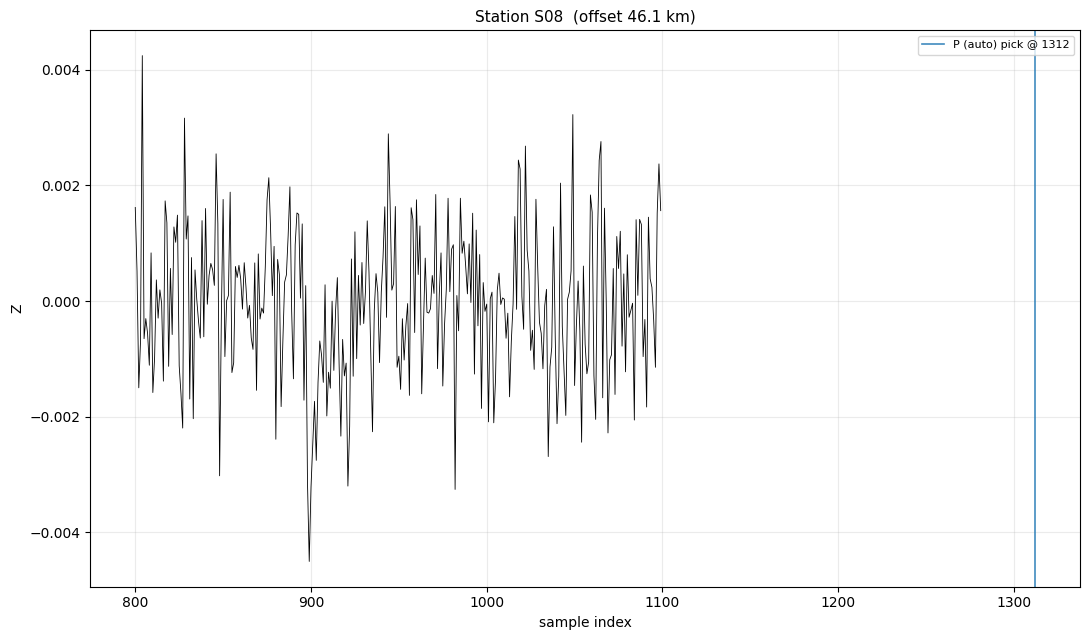

In [12]:
# Tight zoom on S08's true onset region
plot_station('S08', NETWORK,
             picks={'P (auto)': auto_picks['S08']['P']},
             sample_range=(800, 1100), components=('Z',))

That eyeball pick around sample **893** is what we'll use. (For an
S08 S-arrival the auto-pick of ~1548 already looks reasonable from
the per-station overlay, so leave it.)

The cell below copies the auto-picks and applies the manual
override. The cell after this one validates against ground truth
and shows residuals.

In [13]:
# Start from the auto-picks; edit any that look wrong.
picks = {name: dict(p) for name, p in auto_picks.items()}

# --- manual overrides based on visual inspection ---
picks['S08']['P'] = 893     # auto-picker latched onto a later phase
# Add more overrides here as needed.
# ----------------------------------------------------

print('Current picks:')
for name in sorted(picks):
    p, s = picks[name]['P'], picks[name]['S']
    dt = NETWORK[name]['dt']
    print(f'  {name}:  P @ sample {p:>5}  ({p*dt:5.2f} s),    '
          f'S @ sample {s:>5}  ({s*dt:5.2f} s)')

Current picks:
  S01:  P @ sample   611  ( 6.11 s),    S @ sample  1053  (10.53 s)
  S02:  P @ sample   722  ( 7.22 s),    S @ sample  1242  (12.42 s)
  S03:  P @ sample   802  ( 8.02 s),    S @ sample  1385  (13.85 s)
  S04:  P @ sample   744  ( 7.44 s),    S @ sample  1275  (12.75 s)
  S05:  P @ sample   694  ( 6.94 s),    S @ sample  1186  (11.86 s)
  S06:  P @ sample   642  ( 6.42 s),    S @ sample  1111  (11.11 s)
  S07:  P @ sample   611  ( 6.11 s),    S @ sample  1057  (10.57 s)
  S08:  P @ sample   893  ( 8.93 s),    S @ sample  1548  (15.48 s)


## 7. Validate against ground truth

We now load the *true* hypocenter and the *true* arrival times that
were used to synthesize the seismograms in Notebook 01. The validation
plot shows your picks vs the truth: pick residuals are
$\Delta t = t_\text{pick} - t_\text{true}$ in milliseconds.

A good pick set has residuals within a few sample intervals
(few × 10 ms). Systematic bias (all picks late) is also normal: the
*onset* is hard to identify exactly, and the eye/STA-LTA tend to fire
slightly after the very first motion.

In [14]:
with open(os.path.join(DATA_DIR, 'ground_truth.pkl'), 'rb') as f:
    GT = pickle.load(f)

# Build a lookup of true sample indices.
def true_picks(GT):
    out = {}
    for name, ars in GT['arrivals'].items():
        out[name] = {}
        for ar in ars:
            if ar['label'] == 'P_direct':
                out[name]['P'] = ar['sample_idx']
            elif ar['label'] == 'S_direct':
                out[name]['S'] = ar['sample_idx']
    return out

TRUE = true_picks(GT)


def validate_picks(picks, true_picks, dt):
    '''Compute and return per-station residuals in samples and ms.'''
    rows = []
    for name in sorted(picks):
        for phase in ('P', 'S'):
            k_pick = picks[name].get(phase)
            k_true = true_picks[name].get(phase)
            if k_pick is None or k_true is None: continue
            d_samp = k_pick - k_true
            d_ms = d_samp * dt * 1000
            rows.append({
                'station': name, 'phase': phase,
                'pick': k_pick, 'true': k_true,
                'd_samples': d_samp, 'd_ms': d_ms,
            })
    return rows

residuals = validate_picks(picks, TRUE, NETWORK['S01']['dt'])

print(f'{"station":>8s} {"phase":>5s} {"pick":>6s} {"true":>6s} '
      f'{"Δsamp":>6s} {"Δms":>8s}')
for r in residuals:
    print(f'{r["station"]:>8s} {r["phase"]:>5s} {r["pick"]:>6d} {r["true"]:>6d} '
          f'{r["d_samples"]:>+6d} {r["d_ms"]:>+8.1f}')

import numpy as np
arr = np.array([r['d_ms'] for r in residuals])
print(f'\\nResidual stats:  mean = {arr.mean():+.1f} ms,  '
      f'std = {arr.std():.1f} ms,  max abs = {np.max(np.abs(arr)):.1f} ms')

 station phase   pick   true  Δsamp      Δms
     S01     P    611    608     +3    +30.0
     S01     S   1053   1051     +2    +20.0
     S02     P    722    716     +6    +60.0
     S02     S   1242   1239     +3    +30.0
     S03     P    802    799     +3    +30.0
     S03     S   1385   1383     +2    +20.0
     S04     P    744    736     +8    +80.0
     S04     S   1275   1273     +2    +20.0
     S05     P    694    685     +9    +90.0
     S05     S   1186   1184     +2    +20.0
     S06     P    642    640     +2    +20.0
     S06     S   1111   1108     +3    +30.0
     S07     P    611    609     +2    +20.0
     S07     S   1057   1054     +3    +30.0
     S08     P    893    893     +0     +0.0
     S08     S   1548   1545     +3    +30.0
\nResidual stats:  mean = +33.1 ms,  std = 22.8 ms,  max abs = 90.0 ms


**Plot residuals.** Group by phase to see if there's a P/S bias.

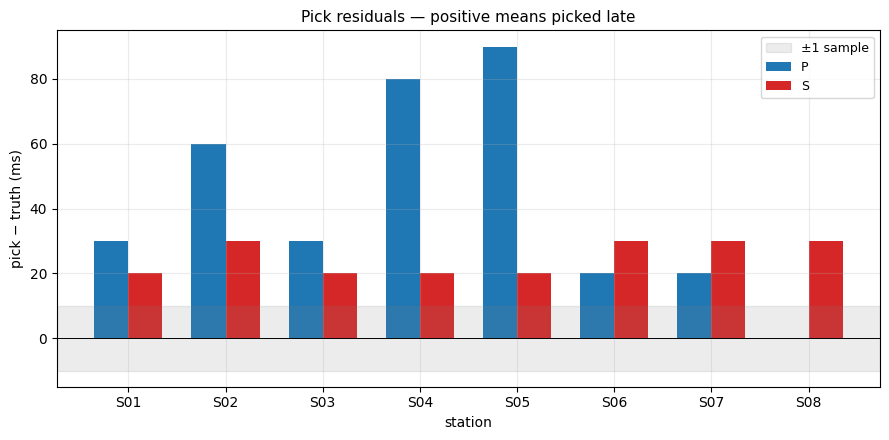

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
station_names = sorted(NETWORK.keys())
x = np.arange(len(station_names))
width = 0.35

for r in residuals:
    i = station_names.index(r['station'])
    if r['phase'] == 'P':
        ax.bar(x[i] - width/2, r['d_ms'], width, color='C0',
               label='P' if i == 0 else None)
    else:
        ax.bar(x[i] + width/2, r['d_ms'], width, color='C3',
               label='S' if i == 0 else None)

ax.axhline(0, color='k', lw=0.7)
ax.axhspan(-10, 10, color='gray', alpha=0.15, label='±1 sample')
ax.set_xticks(x)
ax.set_xticklabels(station_names)
ax.set_ylabel('pick − truth (ms)')
ax.set_xlabel('station')
ax.set_title('Pick residuals — positive means picked late', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Save picks for the inversion notebooks

Notebooks 03–06 will load `data/picks.pkl` and try to recover the
hypocenter from these picks alone. Whatever inversion result you get
is *your picks' fault*, not the algorithms'.

In [16]:
out_path = os.path.join(DATA_DIR, 'picks.pkl')
with open(out_path, 'wb') as f:
    pickle.dump({'picks': picks, 'dt': NETWORK['S01']['dt']}, f)
print(f'Saved {out_path}')
print(f'  Stations picked: {len(picks)}')
print(f'  Phases per station: P + S')

Saved ../data/picks.pkl
  Stations picked: 8
  Phases per station: P + S


## Summary

1. We loaded the synthetic 8-station network from Notebook 01.
2. We defined `plot_station` for sample-indexed inspection of any trace.
3. We defined `sta_lta` and `auto_pick` as a starting suggestion; this
   is the same algorithm used at every regional seismic network in the
   world.
4. We refined the auto-picks where they looked wrong (zero overrides
   are needed for these synthetic data — try adding noise in Notebook 01
   and rerunning to see how picks degrade).
5. We validated against ground truth — residuals within a few samples,
   typical for hand-picked data.
6. We saved the picks for the inversion notebooks.

**Next:** Notebook 03 — Grid search inversion. We'll build a 4D objective
function $\Phi(x, y, z, t_0)$ and brute-force minimize it over a coarse
grid, then a fine grid. Expensive, but a perfect baseline.